<a href="https://colab.research.google.com/github/satvik959/DL-2025-26/blob/main/week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.3394 - val_loss: 0.2713
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2677 - val_loss: 0.2653
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2648 - val_loss: 0.2640
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2639 - val_loss: 0.2634
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2635 - val_loss: 0.2631
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2633 - val_loss: 0.2629
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2632 - val_loss: 0.2629
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2631 - val_loss: 0.2628
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2630 - val_loss: 0.2618
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2594 - val_loss: 0.2570
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2557 - val_loss: 0.2539
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

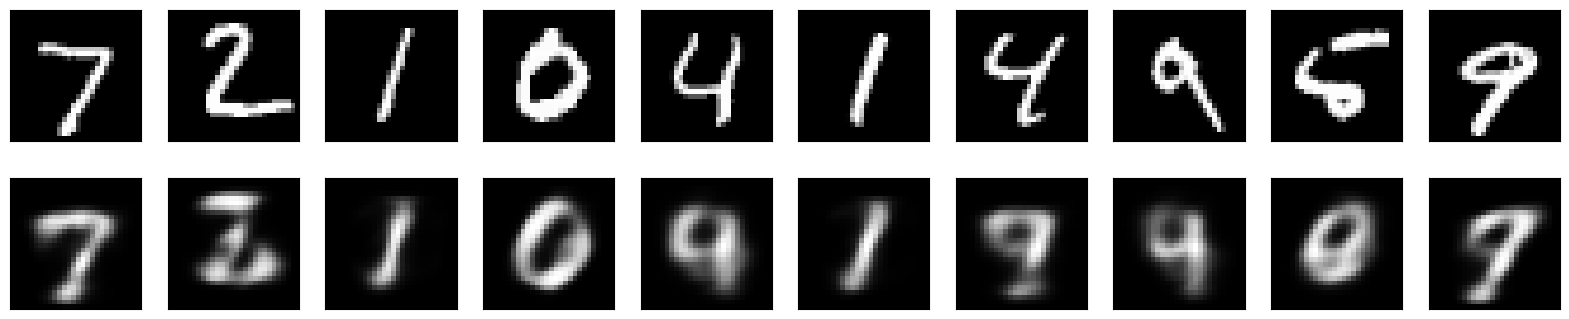

In [3]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 32  # 32 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.2181 - val_loss: 0.1390
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1242 - val_loss: 0.1131
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1093 - val_loss: 0.1035
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1019 - val_loss: 0.0977
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0970 - val_loss: 0.0940
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0936 - val_loss: 0.0912
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0911 - val_loss: 0.0892
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0890 - val_loss: 0.0875
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0874 - val_loss: 0.0855
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0858 - val_loss: 0.0847
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0846 - val_loss: 0.0832
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

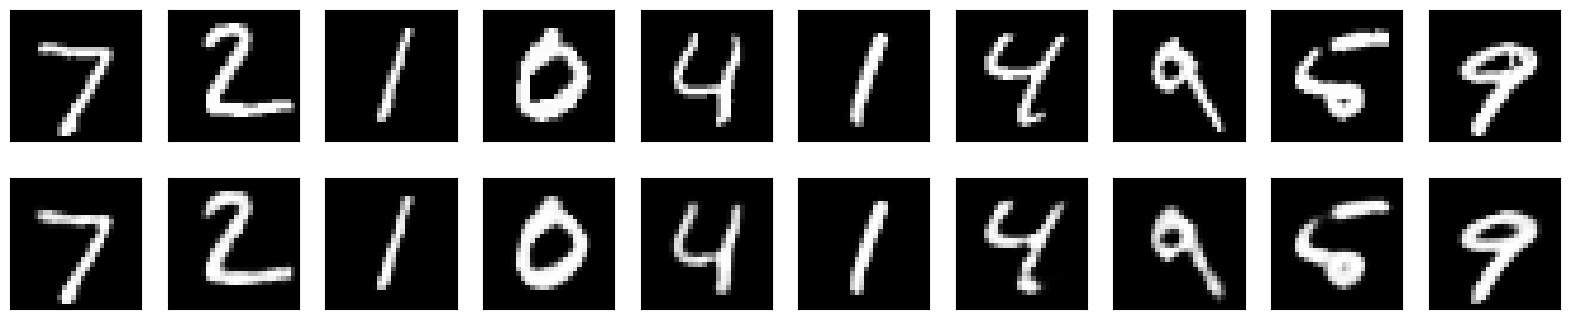

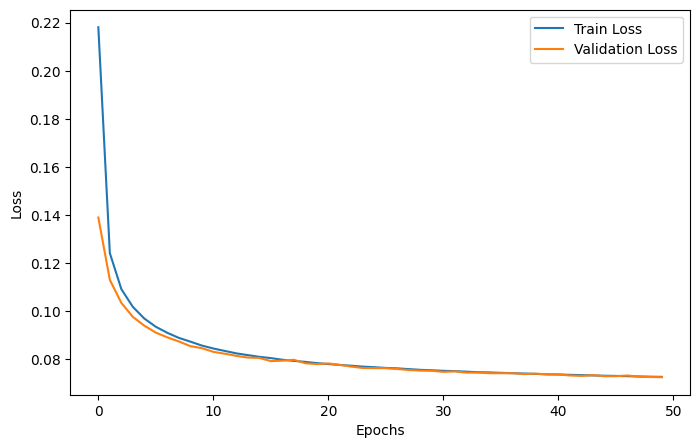

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

input_dim = 784
encoding_dim = 64

input_layer = Input(shape=(input_dim,))
x = Dense(256, activation="relu")(input_layer)
x = Dense(128, activation="relu")(x)
encoded = Dense(encoding_dim, activation="relu")(x)

x = Dense(128, activation="relu")(encoded)
x = Dense(256, activation="relu")(x)
decoded = Dense(input_dim, activation="sigmoid")(x)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = autoencoder.fit(
    x_train,
    x_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    callbacks=[early_stop]
)

decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.2792 - val_loss: 0.2630
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2529 - val_loss: 0.2422
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2395 - val_loss: 0.2359
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2342 - val_loss: 0.2306
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2228 - val_loss: 0.2087
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2030 - val_loss: 0.1980
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1947 - val_loss: 0.1910
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1888 - val_loss: 0.1860
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1841 - val_loss: 0.1813
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1790 - val_loss: 0.1744
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1717 - val_loss: 0.1685
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

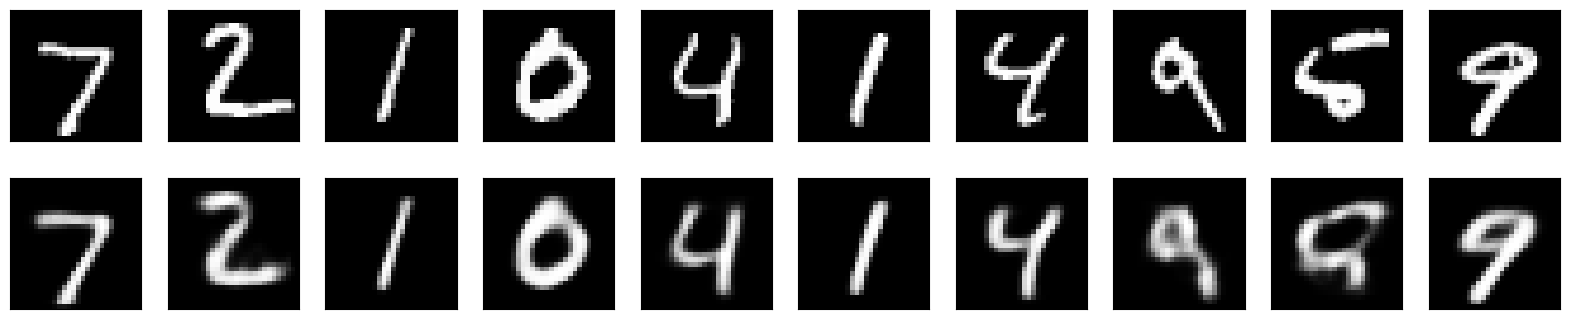

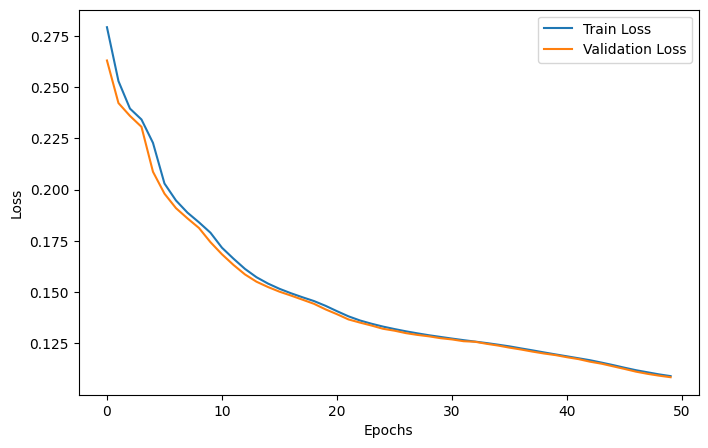

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

input_dim = 784
encoding_dim = 64

input_layer = Input(shape=(input_dim,))
x = Dense(256, activation="sigmoid")(input_layer)
x = Dense(128, activation="sigmoid")(x)
encoded = Dense(encoding_dim, activation="sigmoid")(x)

x = Dense(128, activation="sigmoid")(encoded)
x = Dense(256, activation="sigmoid")(x)
decoded = Dense(input_dim, activation="sigmoid")(x)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = autoencoder.fit(
    x_train,
    x_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    callbacks=[early_stop]
)

decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.2148 - val_loss: 0.1395
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1248 - val_loss: 0.1130
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1089 - val_loss: 0.1035
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1009 - val_loss: 0.0968
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0959 - val_loss: 0.0936
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0926 - val_loss: 0.0902
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0901 - val_loss: 0.0883
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0882 - val_loss: 0.0865
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0866 - val_loss: 0.0851
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0852 - val_loss: 0.0839
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0840 - val_loss: 0.0830
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

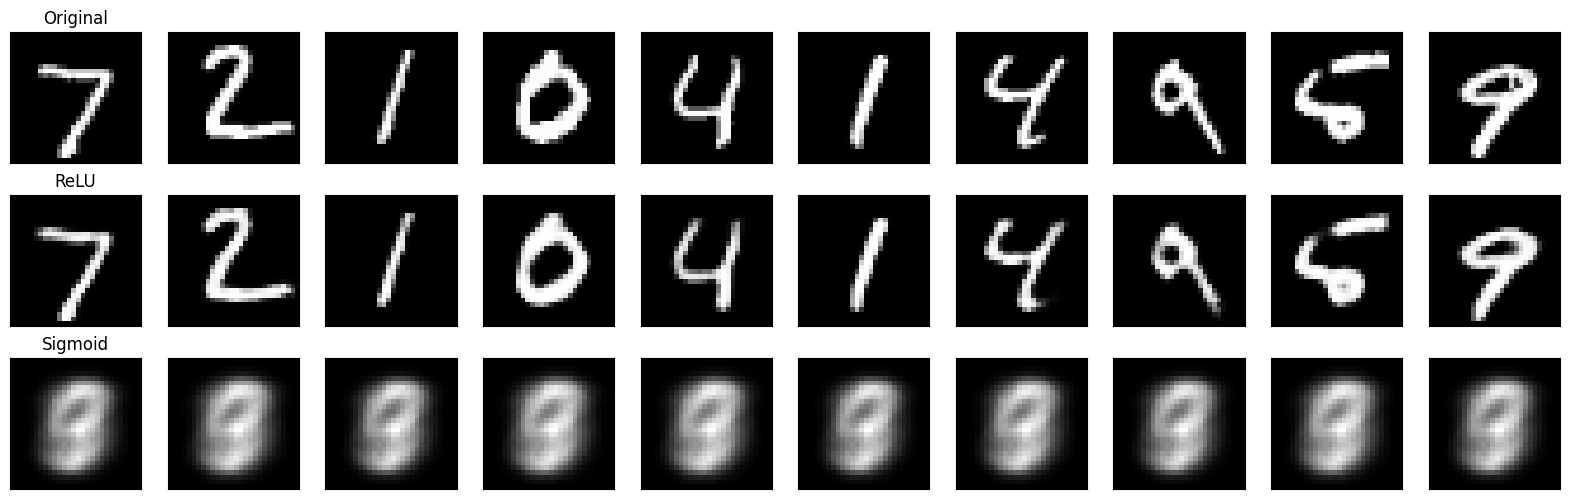

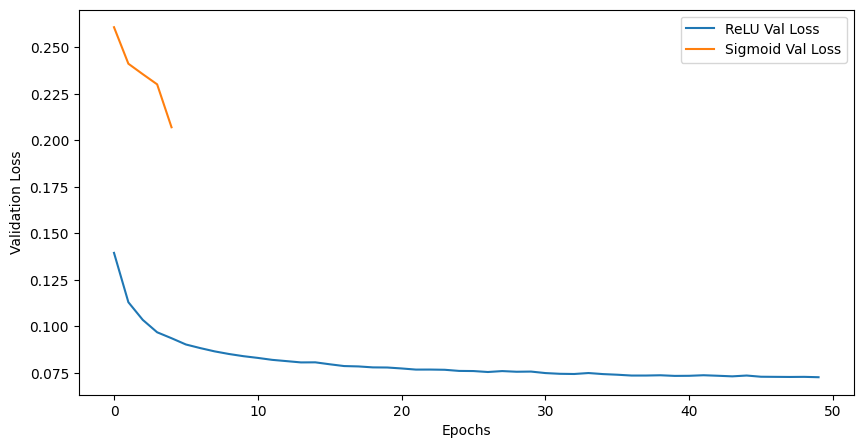

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

input_dim = 784
encoding_dim = 64

def build_autoencoder(hidden_activation="relu"):
    input_layer = Input(shape=(input_dim,))
    x = Dense(256, activation=hidden_activation)(input_layer)
    x = Dense(128, activation=hidden_activation)(x)
    encoded = Dense(encoding_dim, activation=hidden_activation)(x)

    x = Dense(128, activation=hidden_activation)(encoded)
    x = Dense(256, activation=hidden_activation)(x)
    decoded = Dense(input_dim, activation="sigmoid")(x)

    model = Model(input_layer, decoded)
    model.compile(optimizer="adam", loss="binary_crossentropy")
    return model

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

relu_autoencoder = build_autoencoder("relu")
relu_history = relu_autoencoder.fit(
    x_train,
    x_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    callbacks=[early_stop],
    verbose=1
)

relu_decoded = relu_autoencoder.predict(x_test)

sigmoid_autoencoder = build_autoencoder("sigmoid")
sigmoid_history = sigmoid_autoencoder.fit(
    x_train,
    x_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    callbacks=[early_stop],
    verbose=1
)

sigmoid_decoded = sigmoid_autoencoder.predict(x_test)

print("Final ReLU Train Loss:", relu_history.history["loss"][-1])
print("Final ReLU Val Loss:", relu_history.history["val_loss"][-1])
print("Final Sigmoid Train Loss:", sigmoid_history.history["loss"][-1])
print("Final Sigmoid Val Loss:", sigmoid_history.history["val_loss"][-1])

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Original")

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(relu_decoded[i].reshape(28, 28), cmap="gray")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("ReLU")

    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(sigmoid_decoded[i].reshape(28, 28), cmap="gray")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Sigmoid")

plt.show()

plt.figure(figsize=(10, 5))
plt.plot(relu_history.history["val_loss"], label="ReLU Val Loss")
plt.plot(sigmoid_history.history["val_loss"], label="Sigmoid Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.2122 - val_loss: 0.1356
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1229 - val_loss: 0.1109
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1076 - val_loss: 0.1020
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1008 - val_loss: 0.0977
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0962 - val_loss: 0.0935
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0929 - val_loss: 0.0904
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0905 - val_loss: 0.0885
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0887 - val_loss: 0.0871
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0871 - val_loss: 0.0857
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0857 - val_loss: 0.0842
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0844 - val_loss: 0.0831
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

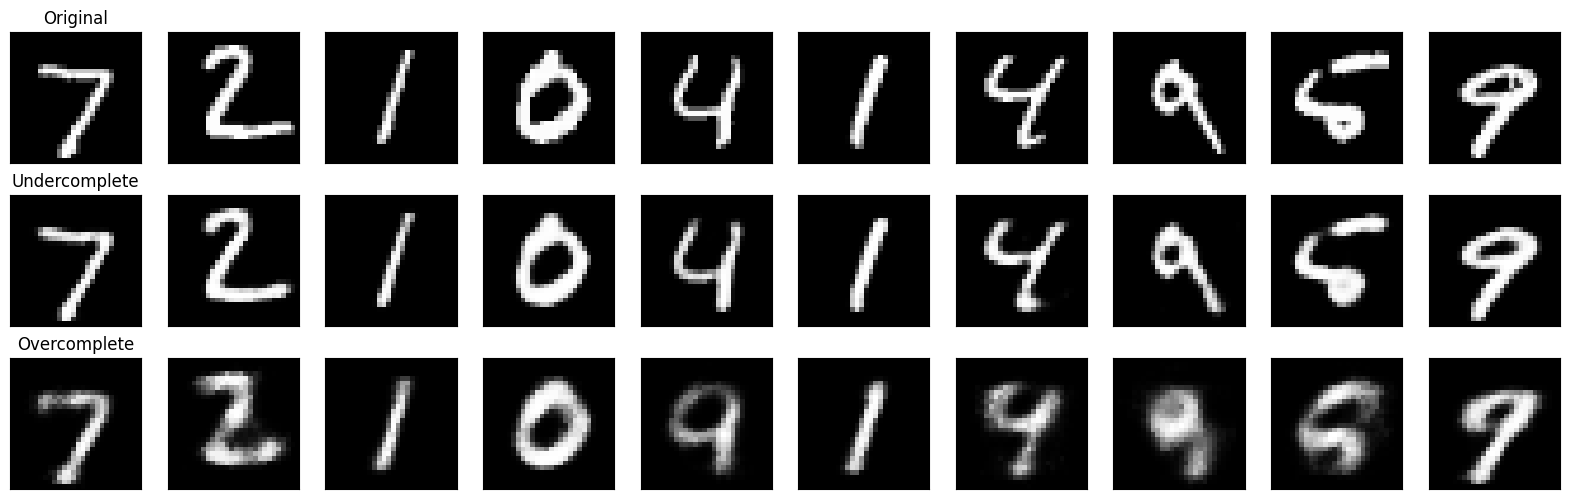

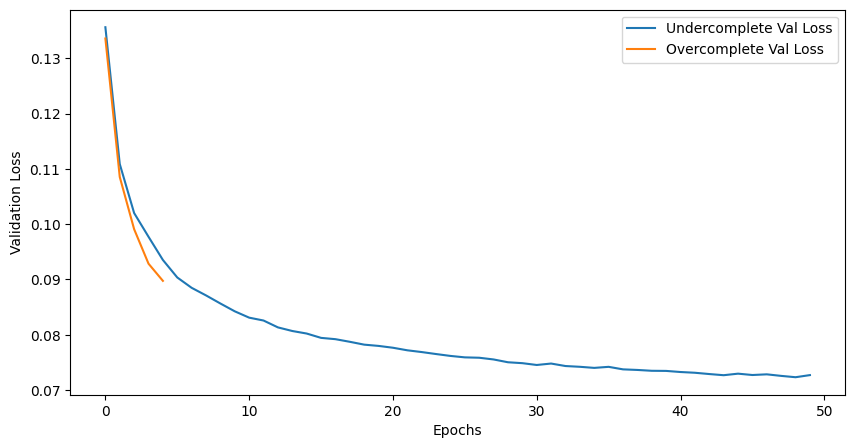

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

input_dim = 784

def build_autoencoder(encoding_dim):
    input_layer = Input(shape=(input_dim,))
    x = Dense(256, activation="relu")(input_layer)
    x = Dense(128, activation="relu")(x)
    encoded = Dense(encoding_dim, activation="relu")(x)

    x = Dense(128, activation="relu")(encoded)
    x = Dense(256, activation="relu")(x)
    decoded = Dense(input_dim, activation="sigmoid")(x)

    model = Model(input_layer, decoded)
    model.compile(optimizer="adam", loss="binary_crossentropy")
    return model

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

undercomplete_dim = 64
overcomplete_dim = 1024

undercomplete_model = build_autoencoder(undercomplete_dim)
undercomplete_history = undercomplete_model.fit(
    x_train,
    x_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    callbacks=[early_stop],
    verbose=1
)

overcomplete_model = build_autoencoder(overcomplete_dim)
overcomplete_history = overcomplete_model.fit(
    x_train,
    x_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    callbacks=[early_stop],
    verbose=1
)

undercomplete_decoded = undercomplete_model.predict(x_test)
overcomplete_decoded = overcomplete_model.predict(x_test)

print("Undercomplete Final Train Loss:", undercomplete_history.history["loss"][-1])
print("Undercomplete Final Val Loss:", undercomplete_history.history["val_loss"][-1])
print("Overcomplete Final Train Loss:", overcomplete_history.history["loss"][-1])
print("Overcomplete Final Val Loss:", overcomplete_history.history["val_loss"][-1])

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Original")

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(undercomplete_decoded[i].reshape(28, 28), cmap="gray")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Undercomplete")

    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(overcomplete_decoded[i].reshape(28, 28), cmap="gray")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Overcomplete")

plt.show()

plt.figure(figsize=(10, 5))
plt.plot(undercomplete_history.history["val_loss"], label="Undercomplete Val Loss")
plt.plot(overcomplete_history.history["val_loss"], label="Overcomplete Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()


Training Autoencoder with latent dimension = 4
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.2641 - val_loss: 0.2121
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1879 - val_loss: 0.1734
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1689 - val_loss: 0.1653
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1630 - val_loss: 0.1613
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1597 - val_loss: 0.1588
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1575 - val_loss: 0.1569
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1559 - val_loss: 0.1557
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1547 - val_loss: 0.1548
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1536 - val_loss: 0.1537
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1527 - val_loss: 0.1531
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1519 - val_loss: 0.1524
Epo

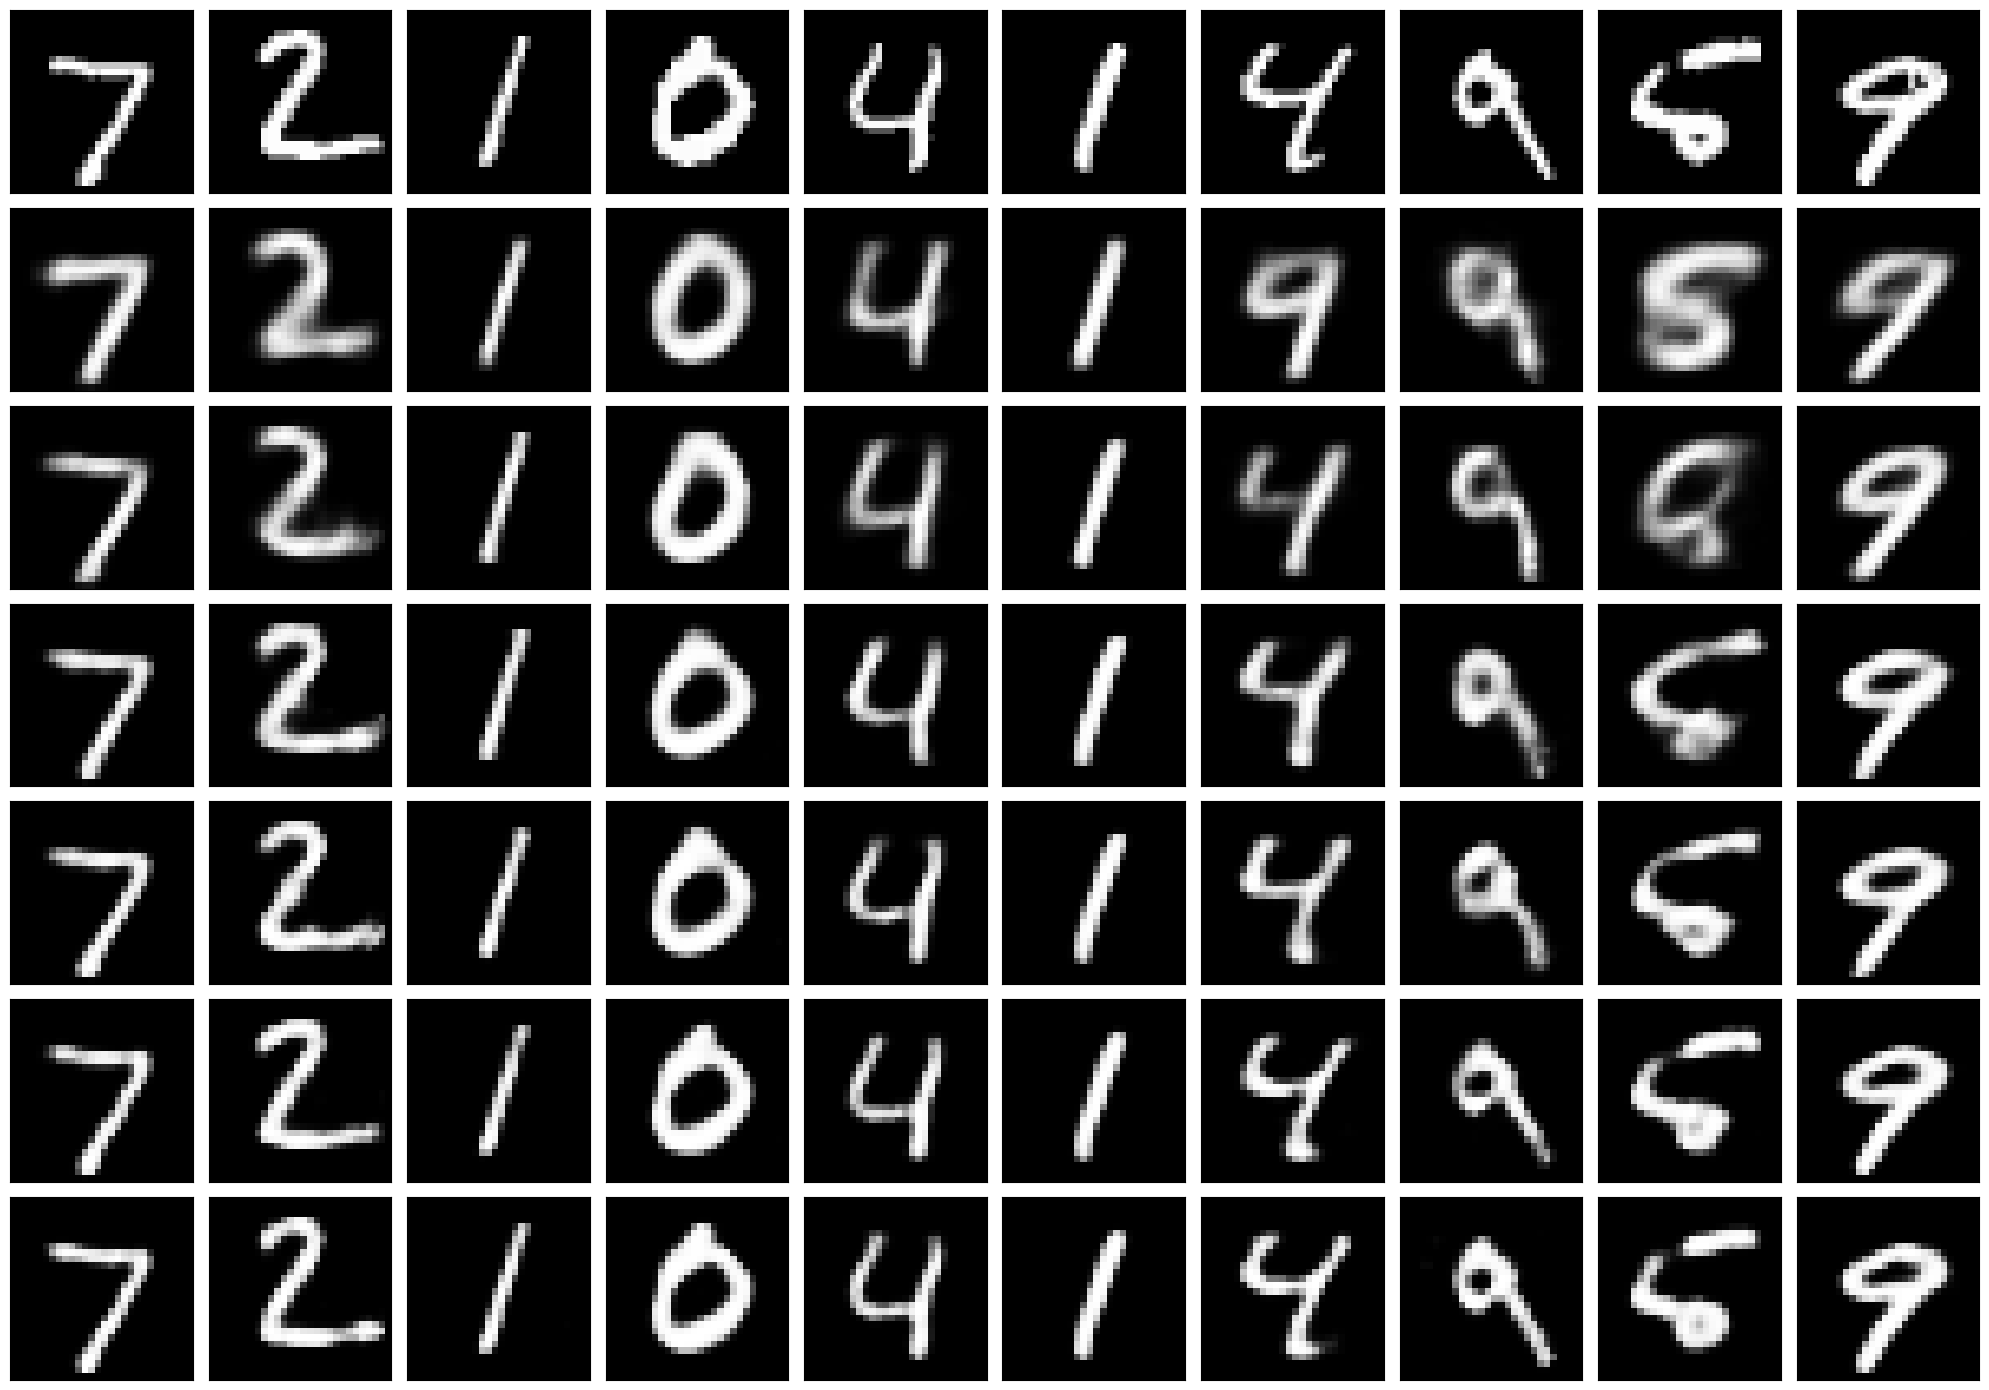

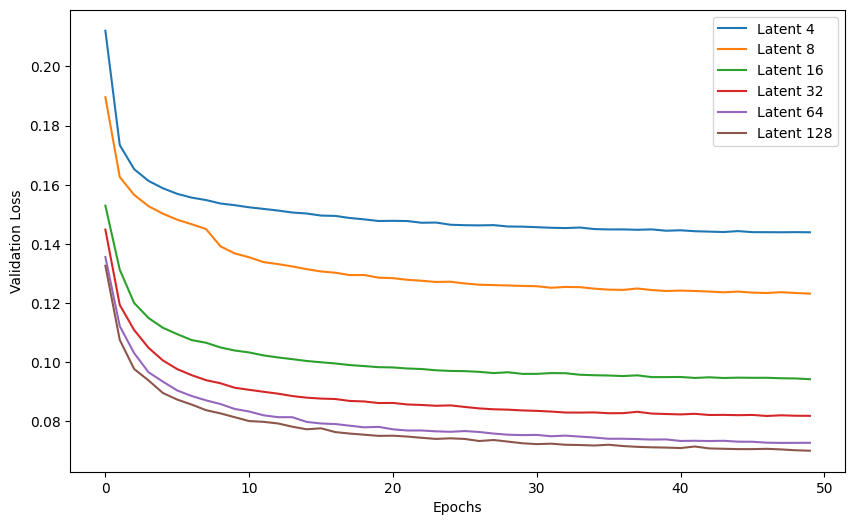

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

input_dim = 784
latent_dims = [4, 8, 16, 32, 64, 128]

def build_autoencoder(latent_dim):
    input_layer = Input(shape=(input_dim,))
    x = Dense(256, activation="relu")(input_layer)
    x = Dense(128, activation="relu")(x)
    encoded = Dense(latent_dim, activation="relu")(x)

    x = Dense(128, activation="relu")(encoded)
    x = Dense(256, activation="relu")(x)
    decoded = Dense(input_dim, activation="sigmoid")(x)

    model = Model(input_layer, decoded)
    model.compile(optimizer="adam", loss="binary_crossentropy")
    return model

histories = {}
decoded_results = {}
final_losses = {}

for latent_dim in latent_dims:
    print(f"\nTraining Autoencoder with latent dimension = {latent_dim}")
    autoencoder = build_autoencoder(latent_dim)

    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    history = autoencoder.fit(
        x_train,
        x_train,
        epochs=50,
        batch_size=256,
        shuffle=True,
        validation_data=(x_test, x_test),
        callbacks=[early_stop],
        verbose=1
    )

    decoded_imgs = autoencoder.predict(x_test)

    histories[latent_dim] = history
    decoded_results[latent_dim] = decoded_imgs
    final_losses[latent_dim] = history.history["val_loss"][-1]

print("\nFINAL VALIDATION LOSSES")
for latent_dim in latent_dims:
    print(f"Latent Dim {latent_dim}: {final_losses[latent_dim]:.4f}")

n = 10
plt.figure(figsize=(20, 2 * (len(latent_dims) + 1)))

for i in range(n):
    ax = plt.subplot(len(latent_dims) + 1, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel("Original", rotation=0, labelpad=40, va="center")

for row, latent_dim in enumerate(latent_dims, start=1):
    for i in range(n):
        ax = plt.subplot(len(latent_dims) + 1, n, row * n + i + 1)
        plt.imshow(decoded_results[latent_dim][i].reshape(28, 28), cmap="gray")
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        if i == 0:
            ax.set_ylabel(f"{latent_dim}", rotation=0, labelpad=30, va="center")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for latent_dim in latent_dims:
    plt.plot(histories[latent_dim].history["val_loss"], label=f"Latent {latent_dim}")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()